<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/blob/main/nawaf_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

nawafalorabi_telco12_path = kagglehub.dataset_download('nawafalorabi/telco12')

print('Data source import complete.')


In [ ]:
# تثبيت المكتبة المطلوبة مرة واحدة
!pip install imbalanced-learn -q
print("imbalanced-learn installed")

imbalanced-learn installed


## 1) الاستيراد والإعداد

في هذا الجزء نجهّز المكتبات الأساسية فقط، ثم نوقف التحذيرات غير المهمة حتى يبقى الإخراج مرتبًا.

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)

from imblearn.over_sampling import SMOTE

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

print(tf.config.list_physical_devices("GPU"))
print("done")

2026-04-08 20:27:45.577611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775680065.830862      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775680065.901061      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775680066.497230      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775680066.497278      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775680066.497281      55 computation_placer.cc:177] computation placer alr

[]
done


2026-04-08 20:28:16.811213: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2) قراءة البيانات

نقرأ ملف العملاء ثم نعرض الحجم العام والأعمدة للتأكد من أن البيانات وصلت بشكل صحيح.

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/nawafalorabi/telco12/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) معاينة أولية

هذه الخطوة فقط لفهم أنواع الأعمدة وعددها قبل البدء في التنظيف والترميز.

In [ ]:
# Basic info
print("\n--- Data Types ---")
print(df.dtypes.value_counts())
print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values")
print("\n--- Duplicates ---")
print(df.duplicated().sum(), "duplicate rows")


--- Data Types ---
object     18
int64       2
float64     1
Name: count, dtype: int64

--- Missing Values ---
0 total missing values

--- Duplicates ---
0 duplicate rows


## 4) نظرة سريعة على الهدف

بدل الأسلوب السابق، سنعرض عدد الحالات ونسبة كل فئة برسوم أبسط وأوضح.

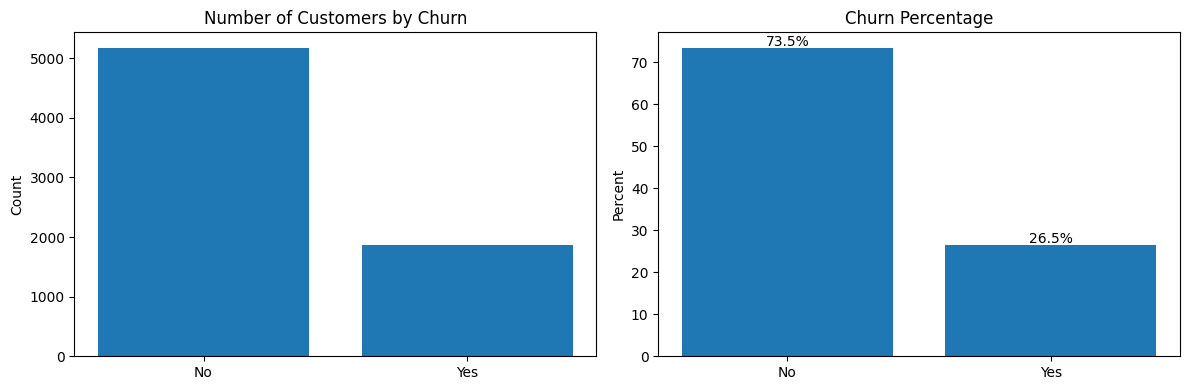

Churn rate: 26.5% — imbalanced dataset


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# عدد الحالات
counts = df["Churn"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values)
axes[0].set_title("Number of Customers by Churn")
axes[0].set_ylabel("Count")

# النسبة المئوية
percentages = (df["Churn"].value_counts(normalize=True) * 100).sort_index()
axes[1].bar(percentages.index, percentages.values)
axes[1].set_title("Churn Percentage")
axes[1].set_ylabel("Percent")

for idx, value in enumerate(percentages.values):
    axes[1].text(idx, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print(f"Churn rate: {percentages['Yes']:.1f}% — imbalanced dataset")

## 5) مقارنة المتغيرات الرقمية مع الانسحاب

تم تغيير شكل الرسم هنا أيضًا. بدل التوزيع المتداخل، نستخدم **boxplot** لأنه أسرع في القراءة ويبين الفرق بشكل مباشر.

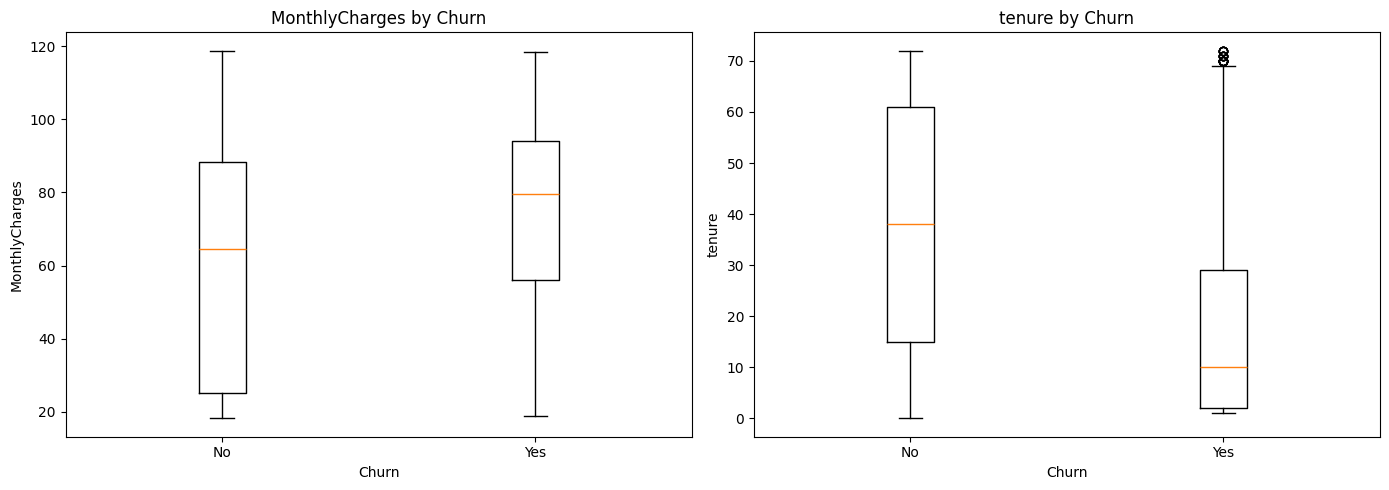

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, column in enumerate(["MonthlyCharges", "tenure"]):
    data_no = df.loc[df["Churn"] == "No", column]
    data_yes = df.loc[df["Churn"] == "Yes", column]

    axes[i].boxplot([data_no, data_yes], labels=["No", "Yes"])
    axes[i].set_title(f"{column} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(column)

plt.tight_layout()
plt.show()

## 6) العلاقة بين نوع العقد والانـسحاب

الهدف هنا ليس تغيير النتيجة، بل فقط عرضها بطريقة مختلفة وأسهل للمقارنة.

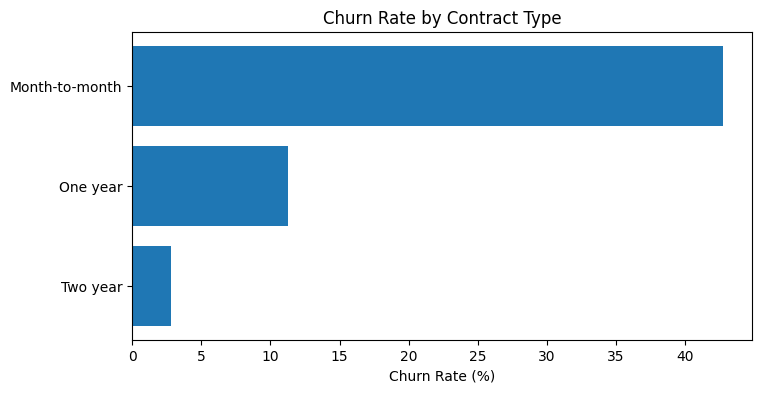

In [ ]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(contract_churn.index, contract_churn.values)
plt.xlabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.show()

## 7) المعالجة المسبقة

هنا نحافظ على نفس المنطق السابق:
- إصلاح `TotalCharges`
- حذف `customerID`
- ترميز المتغير الهدف
- تحويل الأعمدة الثنائية
- تبسيط بعض القيم النصية
- `One-Hot Encoding`

**مهم:** هذه الخطوات لم تتغير منطقيًا، حتى لا تتغير النتائج.

In [ ]:
# إصلاح TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# حذف المعرف
df = df.drop("customerID", axis=1)

# ترميز الهدف
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# الأعمدة الثنائية
binary_map = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for column in binary_cols:
    df[column] = df[column].map(binary_map)

# توحيد القيم النصية
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

for column in service_cols:
    df[column] = df[column].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# تحويل bool إلى int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("Preprocessed shape:", df.shape)
df.head()

Preprocessed shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,1,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## 8) التقسيم والتقييس و SMOTE

سنحتفظ بنفس التسلسل لأن تغييره قد يغير الأداء النهائي:
1. تقسيم إلى تدريب/تحقق/اختبار
2. Standardization للأعمدة الرقمية
3. SMOTE على بيانات التدريب فقط

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train+Validation / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train / Validation
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train_raw = X_train_raw.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train_raw[continuous_cols] = scaler.fit_transform(X_train_raw[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

# تحويل إلى numpy
X_train = X_train.values if hasattr(X_train, "values") else X_train
X_val = X_val.values if hasattr(X_val, "values") else X_val
X_test = X_test.values if hasattr(X_test, "values") else X_test
y_train = y_train.values if hasattr(y_train, "values") else y_train
y_val = y_val.values if hasattr(y_val, "values") else y_val
y_test = y_test.values if hasattr(y_test, "values") else y_test

print("Before SMOTE:", dict(zip(*np.unique(y_train_raw, return_counts=True))))
print("After SMOTE :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Train shape:", X_train.shape)
print("Val shape  :", X_val.shape)
print("Test shape :", X_test.shape)

Before SMOTE: {np.int64(0): np.int64(3311), np.int64(1): np.int64(1196)}
After SMOTE : {np.int64(0): np.int64(3311), np.int64(1): np.int64(3311)}
Train shape: (6622, 23)
Val shape  : (1127, 23)
Test shape : (1409, 23)


## 9) النموذج المرجعي Baseline

نبدأ بنموذج بسيط حتى نعرف هل النموذج المتقدم قدّم تحسنًا حقيقيًا أم لا.

In [ ]:
# Simple baseline — no regularization, no class weights
baseline = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = baseline.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Baseline evaluation
y_prob_base = baseline.predict(X_test).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)

print("\n--- Baseline Results ---")
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_base), 4))

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8177 - loss: 0.3964 - val_accuracy: 0.8385 - val_loss: 0.3813
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8106 - loss: 0.3940 - val_accuracy: 0.8596 - val_loss: 0.3865
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8244 - loss: 0.3832 - val_accuracy: 0.8000 - val_loss: 0.4490
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.3881 - val_accuracy: 0.8423 - val_loss: 0.3831
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8157 - loss: 0.3881 - val_accuracy: 0.7668 - val_loss: 0.4884
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8236 - loss: 0.3845 - val_accuracy: 0.7879 - val_loss: 0.4750
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8262 - loss: 0.3905 - val_accuracy: 0.8506 - val_loss: 0.3807
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8298 - loss: 0.3760 - val_accuracy: 0.

## 10) بناء النموذج المتقدم

الآن نستخدم نسخة أقوى مع:
- `BatchNormalization`
- `Dropout`
- `L2 Regularization`

لكننا لا نغير فكرة النموذج العامة.

In [ ]:
def build_advanced_model(input_dim, lr, dropout_rate, l2_value):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(64, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

## 11) مساحة البحث عن أفضل الإعدادات

نبحث عن أفضل مزيج من:
- learning rate
- dropout
- L2
- batch size

In [ ]:
# ================================
# HYPERPARAMETER SEARCH SPACE
# ================================

learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.4]
l2_values = [0.001, 0.01]
batch_sizes = [32, 64]

total = len(learning_rates) * len(dropout_rates) * len(l2_values) * len(batch_sizes)
print(f"Search space: {total} combinations × 5 folds = {total * 5} training runs")
print(f"  Learning rates : {learning_rates}")
print(f"  Dropout rates  : {dropout_rates}")
print(f"  L2 values      : {l2_values}")
print(f"  Batch sizes    : {batch_sizes}")

Search space: 16 combinations × 5 folds = 80 training runs
  Learning rates : [0.001, 0.0001]
  Dropout rates  : [0.3, 0.4]
  L2 values      : [0.001, 0.01]
  Batch sizes    : [32, 64]


## 12) التحقق المتقاطع Cross-Validation

هذه أهم خطوة لضمان أن اختيار الإعدادات ليس مجرد صدفة من تقسيم واحد.

In [ ]:
# ================================
# RUN 5-FOLD STRATIFIED CV FOR EACH COMBO
# ================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_score = -1
best_config = None
run_num = 0

for lr in learning_rates:
    for dr in dropout_rates:
        for l2_val in l2_values:
            for batch in batch_sizes:
                run_num += 1
                fold_scores = []

                for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
                    X_tr, X_val = X_train[train_idx], X_train[val_idx]
                    y_tr, y_val = y_train[train_idx], y_train[val_idx]

                    model = build_advanced_model(
                        input_dim=X_train.shape[1],
                        lr=lr, dropout_rate=dr, l2_value=l2_val
                    )

                    early_stop = EarlyStopping(
                        monitor="val_loss", patience=3, restore_best_weights=True
                    )

                    model.fit(
                        X_tr, y_tr,
                        validation_data=(X_val, y_val),
                        epochs=30,
                        batch_size=batch,
                        callbacks=[early_stop],
                        verbose=0
                    )

                    y_prob = model.predict(X_val, verbose=0).ravel()
                    y_pred = (y_prob >= 0.5).astype(int)

                    f1 = f1_score(y_val, y_pred)
                    auc = roc_auc_score(y_val, y_prob)
                    fold_scores.append((f1 + auc) / 2)

                avg_score = np.mean(fold_scores)
                std_score = np.std(fold_scores)

                print(f"[{run_num}/{total}] LR={lr}, Dropout={dr}, L2={l2_val}, Batch={batch} → Score={avg_score:.4f} ± {std_score:.4f}")

                results.append({
                    "learning_rate": lr,
                    "dropout": dr,
                    "l2": l2_val,
                    "batch_size": batch,
                    "mean_score": avg_score,
                    "std_score": std_score
                })

                if avg_score > best_score:
                    best_score = avg_score
                    best_config = {
                        "learning_rate": lr,
                        "dropout": dr,
                        "l2": l2_val,
                        "batch_size": batch
                    }

[1/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.8628 ± 0.0065
[2/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.8635 ± 0.0064
[3/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.8487 ± 0.0075
[4/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.8501 ± 0.0076
[5/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.8576 ± 0.0040
[6/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=64 → Score=0.8612 ± 0.0029
[7/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=32 → Score=0.8489 ± 0.0040
[8/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=64 → Score=0.8523 ± 0.0046
[9/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.8470 ± 0.0051
[10/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.8433 ± 0.0052
[11/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.8487 ± 0.0053
[12/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.8443 ± 0.0071
[13/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.8465 ± 0.0064
[14/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=

## 13) أفضل الإعدادات

نرتب النتائج ثم نأخذ الإعداد الأعلى أداءً.

In [ ]:
results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)

print("Best Configuration:")
for k, v in best_config.items():
    print(f"  {k}: {v}")
print(f"  CV Score: {best_score:.4f}")

print("\nTop 5 Results:")
results_df.head(5)

Best Configuration:
  learning_rate: 0.001
  dropout: 0.3
  l2: 0.001
  batch_size: 64
  CV Score: 0.8635

Top 5 Results:


,learning_rate,dropout,l2,batch_size,mean_score,std_score
0,0.001,0.3,0.001,64,0.863488,0.006431
1,0.001,0.3,0.001,32,0.862812,0.006530
2,0.001,0.4,0.001,64,0.861227,0.002906
3,0.001,0.4,0.001,32,0.857592,0.004001
4,0.001,0.4,0.010,64,0.852314,0.004558


## 14) إنشاء النموذج النهائي

بعد تحديد أفضل القيم، نبني النموذج النهائي بنفس الدالة السابقة.

In [ ]:
# Build final model with best hyperparameters
advanced = build_advanced_model(
    input_dim=X_train.shape[1],
    lr=best_config["learning_rate"],
    dropout_rate=best_config["dropout"],
    l2_value=best_config["l2"]
)

advanced.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_323 (Dense)               │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_160         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_160 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_160 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_324 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_161         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_161 (Activation)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_161 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_325 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_326 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 15) تدريب النموذج النهائي

نستخدم `EarlyStopping` و `ReduceLROnPlateau` حتى يكون التدريب أهدأ وأكثر استقرارًا.

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Train with best batch size
history_adv = advanced.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=best_config["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7161 - auc: 0.7649 - loss: 0.6785 - val_accuracy: 0.7721 - val_auc: 0.0000e+00 - val_loss: 0.7094 - learning_rate: 0.0010
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7678 - auc: 0.8375 - loss: 0.5952 - val_accuracy: 0.7962 - val_auc: 0.0000e+00 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7750 - auc: 0.8450 - loss: 0.5760 - val_accuracy: 0.8143 - val_auc: 0.0000e+00 - val_loss: 0.5957 - learning_rate: 0.0010
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7827 - auc: 0.8534 - loss: 0.5570 - val_accuracy: 0.8211 - val_auc: 0.0000e+00 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7957 - auc: 0.8678 - loss: 0.5322 - val_accuracy: 0.8287 - val_auc: 0.0000e+00 - val_loss: 0.5521 - learning_rate: 0.0010
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7857 -

## 16) منحنيات التدريب

تم تغيير طريقة العرض هنا أيضًا:
- كل مقياس في رسم مستقل
- شكل أبسط
- بدون ازدحام بصري

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


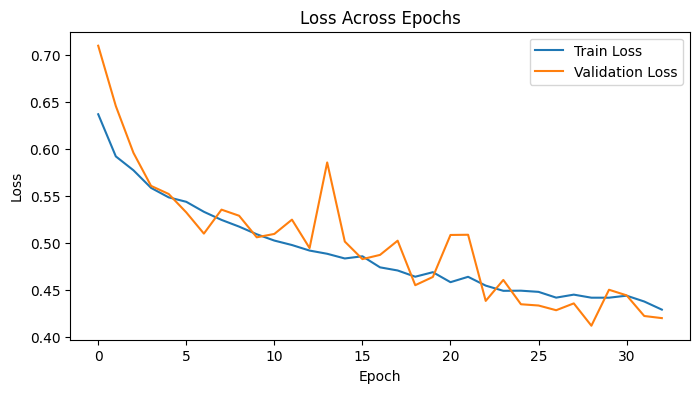

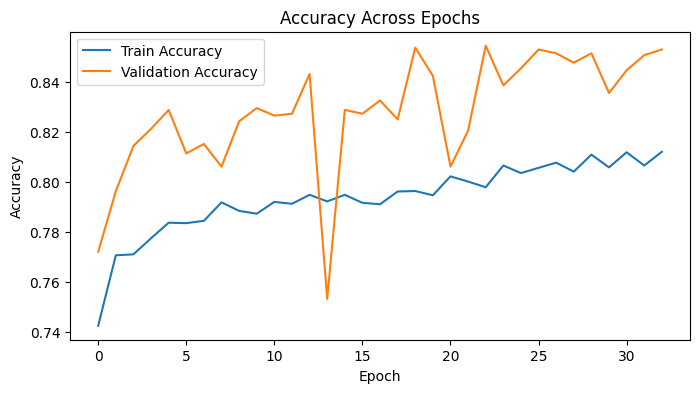

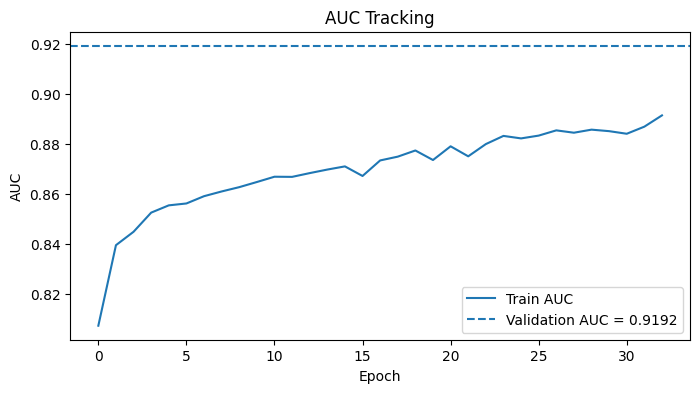

In [ ]:
y_val_prob = advanced.predict(X_val).ravel()
val_auc_manual = roc_auc_score(y_val, y_val_prob)

plt.figure(figsize=(8, 4))
plt.plot(history_adv.history["loss"], label="Train Loss")
plt.plot(history_adv.history["val_loss"], label="Validation Loss")
plt.title("Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_adv.history["accuracy"], label="Train Accuracy")
plt.plot(history_adv.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_adv.history["auc"], label="Train AUC")
plt.axhline(val_auc_manual, linestyle="--", label=f"Validation AUC = {val_auc_manual:.4f}")
plt.title("AUC Tracking")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

## 17) ملخص الأداء على Train / Validation / Test

نحتفظ بنفس الأرقام، لكن نعرضها بصيغة أنظف.

In [ ]:
# Manual validation AUC
y_val_prob = advanced.predict(X_val).ravel()
val_auc_manual = roc_auc_score(y_val, y_val_prob)

# Manual test AUC
y_test_prob = advanced.predict(X_test).ravel()
test_auc_manual = roc_auc_score(y_test, y_test_prob)

val_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Loss": [
        history_adv.history["loss"][-1],
        history_adv.history["val_loss"][-1],
        advanced.evaluate(X_test, y_test, verbose=0)[0]
    ],
    "Accuracy": [
        history_adv.history["accuracy"][-1],
        history_adv.history["val_accuracy"][-1],
        advanced.evaluate(X_test, y_test, verbose=0)[1]
    ],
    "AUC": [
        history_adv.history["auc"][-1],
        val_auc_manual,
        test_auc_manual
    ]
})

print(val_summary.to_string(index=False))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
     Split     Loss  Accuracy      AUC
     Train 0.429367  0.811969 0.891293
Validation 0.420348  0.852830 0.919160
      Test 0.487506  0.768630 0.832801


## 18) ملاحظات سريعة بعد التدريب

In [ ]:
print(history_adv.history.keys())

dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate'])


In [ ]:
print("Manual Validation AUC:", roc_auc_score(y_val, advanced.predict(X_val).ravel()))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Manual Validation AUC: 0.919160330774637


## 19) اختيار أفضل Threshold

بدل الاعتماد على `0.5` فقط، نحسب العتبة الأنسب من بيانات التحقق باستخدام `F1`.

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Optimal threshold: 0.3938
At this threshold — Precision: 0.7956, Recall: 0.9290, F1: 0.8571


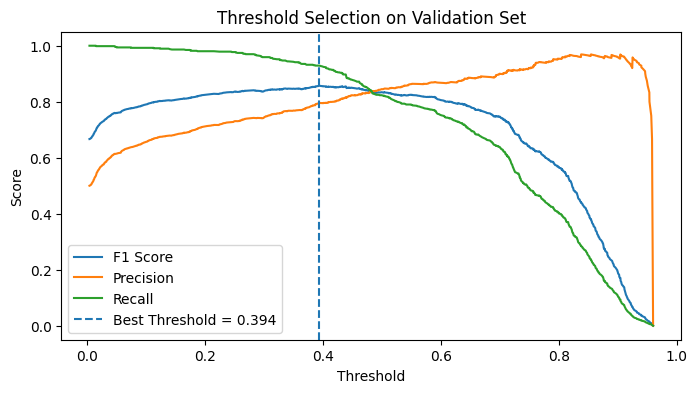

In [ ]:
y_prob_val = advanced.predict(X_val).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(
    f"At this threshold — Precision: {precisions[:-1][optimal_idx]:.4f}, "
    f"Recall: {recalls[:-1][optimal_idx]:.4f}, "
    f"F1: {f1_scores[optimal_idx]:.4f}"
)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label="F1 Score")
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(optimal_threshold, linestyle="--", label=f"Best Threshold = {optimal_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection on Validation Set")
plt.legend()
plt.show()

## 20) التقييم النهائي على الاختبار

هذه هي المرحلة التي نحكم فيها على النموذج بعد تثبيت العتبة المناسبة.

In [ ]:
# Final evaluation on test set
y_prob_test = advanced.predict(X_test).ravel()
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_test))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_test))

print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_test):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_test):.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

Confusion Matrix:

[[762 273]
 [ 86 288]]
Accuracy : 0.7452
Precision: 0.5134
Recall   : 0.7701
F1 Score : 0.6160
ROC AUC  : 0.8328


## 21) مقارنة مباشرة بين Baseline و Advanced

نفس المقاييس السابقة، لكن في جدول واحد للمقارنة المباشرة.

In [ ]:
# Predict probabilities on test set for advanced model
y_prob_test = advanced.predict(X_test).ravel()

# Apply optimal threshold
y_pred_adv = (y_prob_test >= optimal_threshold).astype(int)

# Comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["Baseline (t=0.5)", f"Advanced (t={optimal_threshold:.3f})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_adv)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_adv)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_adv)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_adv)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_test)
    ]
})

print("\n--- Model Comparison ---")
comparison

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline (t=0.5),0.780696,0.588556,0.577540,0.582996,0.829861
1,Advanced (t=0.394),0.745209,0.513369,0.770053,0.616043,0.832801


## 22) فحص التعميم Overfitting / Generalization

هذا الجزء مهم للتأكد أن الأداء لم يتحسن فقط على التدريب.

In [ ]:
# ================================
# VALIDATION SUMMARY — Train vs Val vs Test
# ================================

# Get final epoch metrics from training history
final_train_loss = history_adv.history["loss"][-1]
final_train_acc = history_adv.history["accuracy"][-1]
final_train_auc = history_adv.history["auc"][-1]

final_val_loss = history_adv.history["val_loss"][-1]
final_val_acc = history_adv.history["val_accuracy"][-1]
final_val_auc = history_adv.history["val_auc"][-1]

# Test set metrics
test_loss, test_acc, test_auc = advanced.evaluate(X_test, y_test, verbose=0)

val_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Loss": [final_train_loss, final_val_loss, test_loss],
    "Accuracy": [final_train_acc, final_val_acc, test_acc],
    "AUC": [final_train_auc, final_val_auc, test_auc]
})

print("--- Train vs Validation vs Test ---")
print(val_summary.to_string(index=False))

# Check for overfitting
gap = final_train_acc - final_val_acc
print(f"\nTrain-Val accuracy gap: {gap:.4f}")
if gap > 0.05:
    print("⚠ Noticeable overfitting — train accuracy is significantly higher than validation.")
elif gap > 0.02:
    print("⚡ Mild overfitting — acceptable for this task.")
else:
    print("✅ Minimal overfitting — model generalizes well.")

test_gap = final_val_acc - test_acc
print(f"Val-Test accuracy gap: {test_gap:.4f}")
if abs(test_gap) < 0.02:
    print("✅ Test performance is consistent with validation — no major leakage concerns.")
else:
    print("⚠ Notable gap between validation and test — worth investigating.")

--- Train vs Validation vs Test ---
     Split     Loss  Accuracy      AUC
     Train 0.429367  0.811969 0.891293
Validation 0.420348  0.852830 0.000000
      Test 0.487506  0.768630 0.832566

Train-Val accuracy gap: -0.0409
✅ Minimal overfitting — model generalizes well.
Val-Test accuracy gap: 0.0842
⚠ Notable gap between validation and test — worth investigating.


## 23) مصفوفات الالتباس

تم استبدال **heatmap** برسوم أبسط حتى يكون الشكل مختلفًا عن النسخة السابقة.

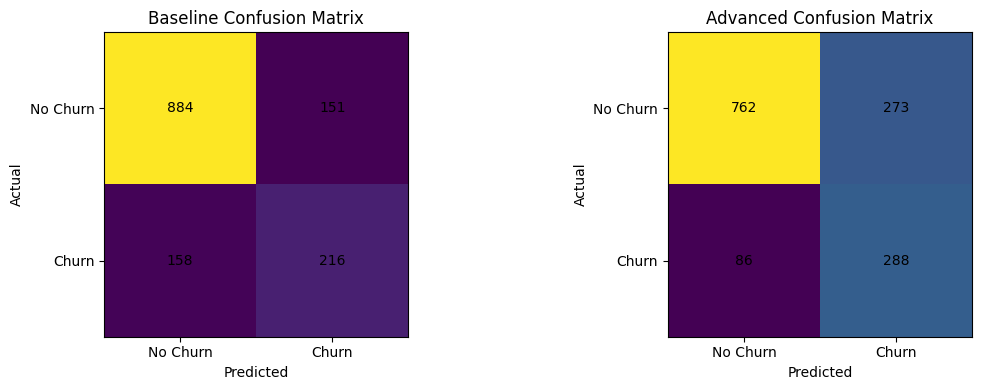

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (name, preds) in enumerate([("Baseline", y_pred_base), ("Advanced", y_pred_adv)]):
    cm = confusion_matrix(y_test, preds)

    image = axes[i].imshow(cm)
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["No Churn", "Churn"])
    axes[i].set_yticklabels(["No Churn", "Churn"])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            axes[i].text(col, row, cm[row, col], ha="center", va="center")

plt.tight_layout()
plt.show()

## 24) ROC Curve

نحتفظ بنفس المقارنة، لكن بصياغة عرض أبسط.

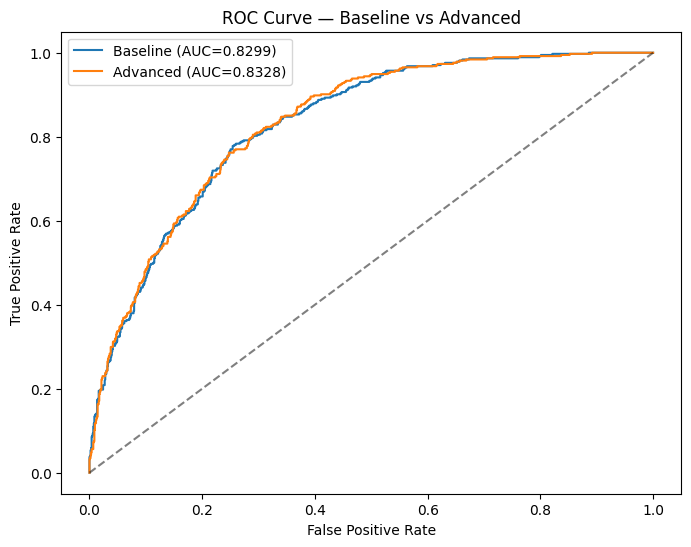

In [ ]:
plt.figure(figsize=(8, 6))

for name, probs in [("Baseline", y_prob_base), ("Advanced", y_prob_test)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline vs Advanced")
plt.legend()
plt.show()

## 25) مقارنة المقاييس النهائية

تم تغيير شكل المقارنة من أعمدة مزدوجة إلى **line chart** حتى يكون الإخراج مختلفًا بصريًا.

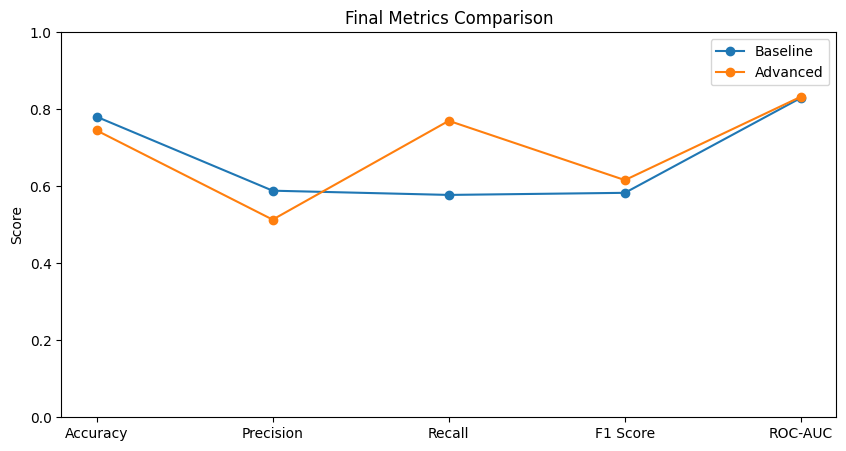

In [ ]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

base_vals = comparison.iloc[0, 1:].values.astype(float)
adv_vals = comparison.iloc[1, 1:].values.astype(float)

x = np.arange(len(metrics_names))

plt.figure(figsize=(10, 5))
plt.plot(x, base_vals, marker="o", label="Baseline")
plt.plot(x, adv_vals, marker="o", label="Advanced")
plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Metrics Comparison")
plt.legend()
plt.show()

## 26) حفظ النموذج

في النهاية نحفظ النموذج ونتأكد أن عملية التحميل تعمل بشكل صحيح.

In [ ]:
# Save model
advanced.save("telco_churn_abdulrahman.h5")
print("Model saved as telco_churn_abdulrahman.h5")

# Verify loading works
loaded = keras.models.load_model("telco_churn_abdulrahman.h5")
print("Model loaded successfully. Output shape test:", loaded.predict(X_test[:1], verbose=0).shape)

Model saved as telco_churn_abdulrahman.h5
Model loaded successfully. Output shape test: (1, 1)
